In [1]:
!nvidia-smi

Fri Apr  3 03:30:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             50W /  400W |     478MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
!pip install nibabel SimpleITK antspyx scikit-image scipy torch torchvision tqdm pandas matplotlib

##  Imports & Config

In [3]:
import os, glob, json, warnings
from pathlib import Path
from typing import Tuple, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import nibabel as nib
import SimpleITK as sitk
from scipy.ndimage import label, binary_fill_holes, gaussian_filter
from scipy.interpolate import splprep, splev
from skimage.transform import hough_circle, hough_circle_peaks
from skimage.feature import canny
from skimage.morphology import skeletonize, binary_dilation, ball
from skimage.measure import regionprops
from skimage.exposure import equalize_adapthist
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
warnings.filterwarnings("ignore")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_ROOT  = Path("/content/drive/MyDrive/release")          # folder containing subj001..subj200
# TEST_ROOT  = Path("release_test")     # folder containing 30 test subjects
OUT_DIR    = Path("/content/drive/MyDrive/MIA_project_2")
OUT_DIR.mkdir(exist_ok=True)

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Hyper-parameters ───────────────────────────────────────────────────────────
CFG = dict(
    patch_size   = (96, 96, 96),
    batch_size   = 2,
    lr           = 1e-4,
    epochs_a     = 100,     # Task A artifact U-Net
    epochs_b     = 150,     # Task B catheter U-Net
    val_frac     = 0.20,
    n_workers    = 4,
    cht_sigma    = 2.0,     # CHT Canny sigma
    cht_r_min    = 6,       # min artifact radius (voxels)
    cht_r_max    = 22,      # max artifact radius (voxels)
)


Device: cuda


## 2  Data Utilities

In [9]:
def load_nifti(path: Path) -> Tuple[np.ndarray, np.ndarray, nib.Nifti1Image]:
    """Return (data_float32, voxel_spacing_mm, nibabel_img)."""
    img  = nib.load(str(path))
    data = img.get_fdata(dtype=np.float32)
    spacing = np.array(img.header.get_zooms()[:3], dtype=np.float32)
    return data, spacing, img

def save_nifti(mask: np.ndarray, ref_img: nib.Nifti1Image, path: Path):
    """Save uint8 binary mask in the reference voxel space."""
    out = nib.Nifti1Image(mask.astype(np.uint8), ref_img.affine, ref_img.header)
    nib.save(out, str(path))

def get_subject_paths(root: Path, labeled: bool = True) -> List[dict]:
    """Return sorted list of per-subject path dicts."""
    subjects = sorted(root.glob("subj*"))
    records  = []
    for s in subjects:
        sid  = s.name
        rec  = {"id": sid, "image": s / f"{sid}_image.nii.gz"}
        if labeled:
            rec["artifact"] = s / f"{sid}_artifact.nii.gz"
            rec["catheter"] = s / f"{sid}_catheter.nii.gz"
        records.append(rec)
    return records

# Quick sanity-check on one subject
if DATA_ROOT.exists():
    records = get_subject_paths(DATA_ROOT)
    r0 = records[0]
    img, sp, _ = load_nifti(r0["image"])
    print(f"Subjects: {len(records)} | Volume shape: {img.shape} | Spacing: {sp} mm")


Subjects: 10 | Volume shape: (192, 224, 192) | Spacing: [1. 1. 1.] mm


## 3  Preprocessing

Steps (in order):
1. **N4 bias-field correction** (SimpleITK) — removes low-frequency intensity inhomogeneity
2. **Adaptive histogram equalization** (CLAHE, per-slice) — normalises contrast across scanners
3. **Intensity normalisation** — clip to [0.5%, 99.5%] then z-score

> **Note on registration:** atlas-based (MNI-152) registration is *optional* and slows  
> inference significantly. The U-Nets below operate in native space; enable  
> `USE_REGISTRATION = True` only if CHT performance is poor due to orientation variance.


In [12]:
USE_REGISTRATION = False   # flip to True to enable ANTs MNI registration

def n4_bias_correct(sitk_img: sitk.Image) -> sitk.Image:
    corrector = sitk.N4BiasFieldCorrectionImageFilter()
    corrector.SetMaximumNumberOfIterations([50, 50, 50, 50])
    return corrector.Execute(sitk_img)

def clahe_volume(vol: np.ndarray) -> np.ndarray:
    """Apply 2-D CLAHE slice-by-slice along the axial axis."""
    out = np.zeros_like(vol)
    v_min, v_max = vol.min(), vol.max()
    vol_norm = (vol - v_min) / (v_max - v_min + 1e-8)
    for z in range(vol.shape[2]):
        out[..., z] = equalize_adapthist(vol_norm[..., z], clip_limit=0.03)
    return out

def intensity_normalise(vol: np.ndarray) -> np.ndarray:
    lo, hi = np.percentile(vol, 0.5), np.percentile(vol, 99.5)
    vol    = np.clip(vol, lo, hi)
    return (vol - vol.mean()) / (vol.std() + 1e-8)

CACHE_DIR = Path("preproc_cache")
CACHE_DIR.mkdir(exist_ok=True)

def preprocess_volume(path: Path, use_cache: bool = True) -> np.ndarray:
    """
    Full preprocessing: N4 -> CLAHE -> z-score.
    Cached to disk so N4 only runs once per subject.
    Output shape is always (X,Y,Z) to match nibabel convention.
    """
    cache_key  = Path(path).name.replace('.nii.gz','').replace('.nii','')
    cache_path = CACHE_DIR / (cache_key + '_pre.npy')
    if use_cache and cache_path.exists():
        return np.load(str(cache_path))

    sitk_img  = sitk.ReadImage(str(path), sitk.sitkFloat32)
    sitk_img  = n4_bias_correct(sitk_img)
    # sitk returns (Z, Y, X); transpose to (X, Y, Z) == nibabel order
    vol       = sitk.GetArrayFromImage(sitk_img).transpose(2, 1, 0)

    # Shape guard -- fails loudly if axis ordering is wrong
    ref_shape = nib.load(str(path)).shape[:3]
    assert vol.shape == ref_shape, (
        f"preprocess_volume shape mismatch: sitk gave {vol.shape}, "
        f"nibabel expects {ref_shape}. Check scanner axis ordering.")

    vol = clahe_volume(vol)
    vol = intensity_normalise(vol).astype(np.float32)
    if use_cache:
        np.save(str(cache_path), vol)
    return vol
# ── Optional MNI registration via ANTsPy ───────────────────────────────────────
if USE_REGISTRATION:
    import ants

    MNI_TEMPLATE = "MNI152_T1_1mm.nii.gz"   # download separately if needed

    def register_to_mni(moving_path: Path):
        fixed   = ants.image_read(MNI_TEMPLATE)
        moving  = ants.image_read(str(moving_path))
        result  = ants.registration(fixed, moving, type_of_transform="Affine")
        return result["warpedmovout"], result["fwdtransforms"], result["invtransforms"]

    def transform_mask_to_native(mask_mni, inv_tx, ref_path: Path):
        ref    = ants.image_read(str(ref_path))
        native = ants.apply_transforms(ref, mask_mni, transformlist=inv_tx,
                                       interpolator="nearestNeighbor")
        return native.numpy()


## 4  Task A — Valve Artifact Detection

### 4a  Circular Hough Transform Baseline

  Skull shell: 3711375 voxels (44.9% of volume)  [target ~5-8%]
  CHT peak @ (160,201,173)  acc=1.6353
CHT baseline DSC: 0.0000
  DSC < 0.50 on subj001 — CHT baseline not reliable.
  Proceeding directly to 3D U-Net (Section 4e).
Artifact at z=54  (mid-brain z=96)


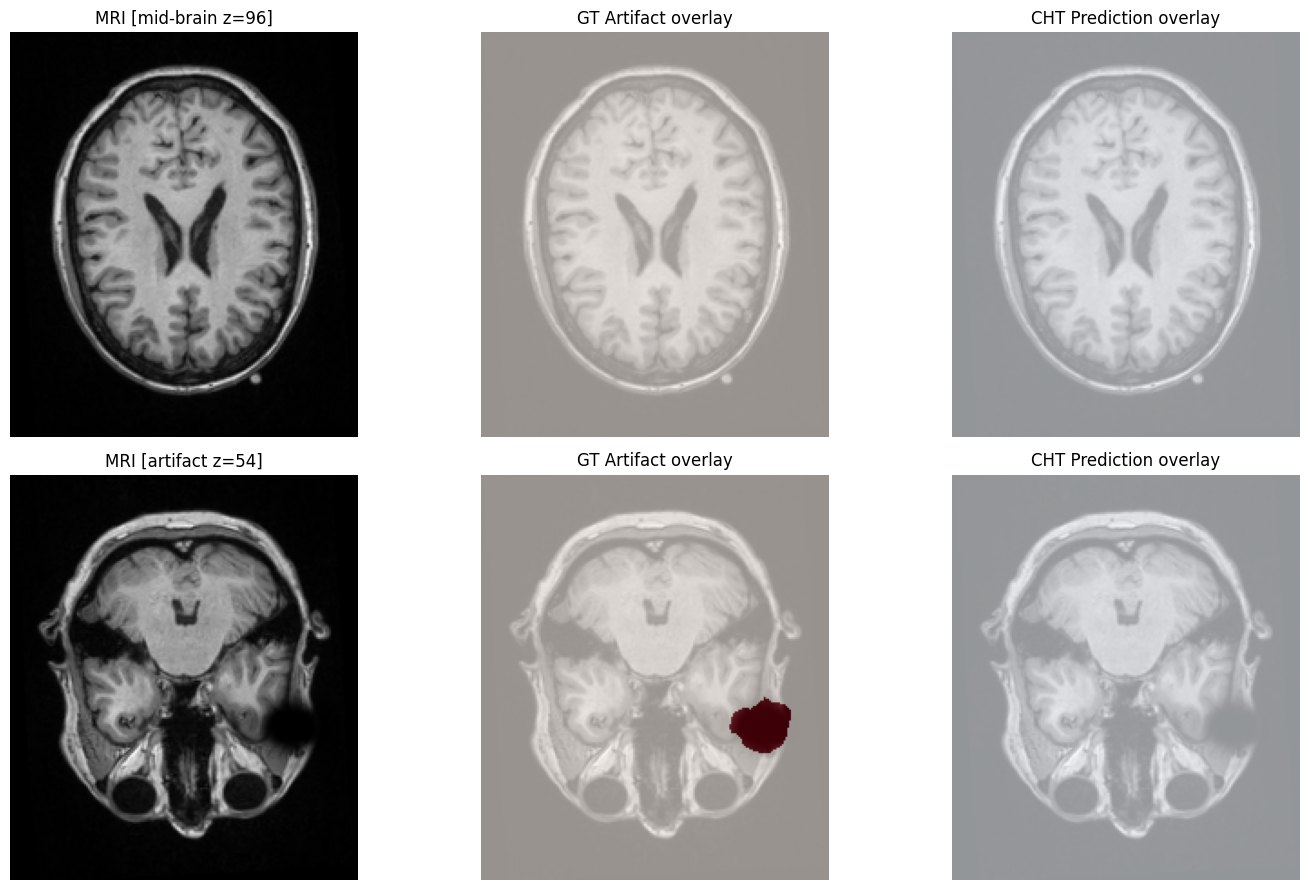

In [14]:
def build_skull_shell_mask(vol_raw: np.ndarray,
                            spacing: np.ndarray,
                            shell_thickness_mm: float = 20.0) -> np.ndarray:
    """
    Skull/scalp shell mask built on the RAW (non-CLAHE) volume.

    CLAHE lifts the MRI air background to mid-range intensities, so Otsu
    on a CLAHE volume incorrectly labels background as tissue and produces
    a shell that covers ~40% of the volume. Raw MRI background is truly
    near-zero, so a simple percentile threshold works cleanly.
    """
    from scipy.ndimage import binary_erosion, binary_fill_holes

    # Background in MRI is ~0; threshold at 2nd percentile of nonzero voxels
    nonzero   = vol_raw[vol_raw > 0]
    thresh    = np.percentile(nonzero, 2) if len(nonzero) else 0.01
    head_raw  = vol_raw > thresh
    head_mask = binary_fill_holes(head_raw)

    shell_vox = max(1, int(round(shell_thickness_mm / spacing.mean())))
    struct    = ball(shell_vox)
    eroded    = binary_erosion(head_mask, structure=struct)
    shell     = head_mask & ~eroded
    coverage  = 100 * shell.mean()
    print(f"  Skull shell: {shell.sum()} voxels ({coverage:.1f}% of volume)"
          f"  [target ~5-8%]")
    if coverage > 15:
        print("  WARNING: shell still large — check that vol_raw is the "
              "nibabel-loaded array, not the CLAHE-preprocessed one.")
    return shell.astype(bool)


def cht_artifact_mask(vol_raw: np.ndarray,
                      vol_pre: np.ndarray,
                      spacing: np.ndarray,
                      sigma: float = 1.5,
                      r_min_mm: float = 8.0,
                      r_max_mm: float = 25.0,
                      shell_thickness_mm: float = 20.0) -> np.ndarray:
    """
    Orientation-agnostic CHT artifact detector.

    vol_raw : nibabel-loaded array (used only for skull shell computation)
    vol_pre : CLAHE-preprocessed array (used for Canny edge detection)

    Key: skull shell is computed on vol_raw to avoid CLAHE background lift.
    """
    X, Y, Z  = vol_pre.shape
    sp_mean  = spacing.mean()
    r_min_v  = max(2, int(round(r_min_mm  / sp_mean)))
    r_max_v  = max(r_min_v + 1, int(round(r_max_mm / sp_mean)))
    radii    = np.arange(r_min_v, r_max_v + 1)

    shell_mask  = build_skull_shell_mask(vol_raw, spacing, shell_thickness_mm)

    # Intensity prior on raw volume: artifact = dark void relative to shell
    shell_vals   = vol_raw[shell_mask]
    thresh_dark  = np.percentile(shell_vals, 5)
    dark_weight  = np.where(vol_raw < thresh_dark, 3.0, 1.0).astype(np.float32)

    acc = np.zeros((X, Y, Z), dtype=np.float32)

    for z in range(Z):
        if not shell_mask[:, :, z].any():
            continue
        edges = canny(vol_pre[:, :, z], sigma=sigma)
        if edges.sum() == 0:
            continue
        hs = hough_circle(edges, radii).max(axis=0)
        acc[:, :, z] += hs * dark_weight[:, :, z] * shell_mask[:, :, z]

    for y in range(Y):
        if not shell_mask[:, y, :].any():
            continue
        edges = canny(vol_pre[:, y, :], sigma=sigma)
        if edges.sum() == 0:
            continue
        hs = hough_circle(edges, radii).max(axis=0)
        acc[:, y, :] += hs * dark_weight[:, y, :] * shell_mask[:, y, :]

    acc = gaussian_filter(acc, sigma=1.5)

    cx_v, cy_v, cz_v = np.unravel_index(np.argmax(acc), acc.shape)
    print(f"  CHT peak @ ({cx_v},{cy_v},{cz_v})  acc={acc[cx_v,cy_v,cz_v]:.4f}")

    r_mm = (r_min_mm + r_max_mm) / 2.0
    xs_g, ys_g, zs_g = np.ogrid[:X, :Y, :Z]
    dist_sq_mm = (((xs_g - cx_v) * spacing[0])**2 +
                  ((ys_g - cy_v) * spacing[1])**2 +
                  ((zs_g - cz_v) * spacing[2])**2)
    return (dist_sq_mm <= r_mm**2).astype(np.uint8)


def find_best_artifact_slice(gt_art: np.ndarray) -> int:
    counts = gt_art.sum(axis=(0, 1))
    return int(np.argmax(counts)) if counts.max() > 0 else gt_art.shape[2] // 2


# ── Demo ──────────────────────────────────────────────────────────────────────
if DATA_ROOT.exists():
    r0 = records[0]
    vol_raw, sp, _ = load_nifti(r0["image"])          # raw: for shell mask
    vol_pre        = preprocess_volume(r0["image"])   # CLAHE: for CHT edges
    gt_art, _, _   = load_nifti(r0["artifact"])

    cht_mask = cht_artifact_mask(vol_raw, vol_pre, sp,
                                 sigma=1.5,
                                 r_min_mm=8.0,
                                 r_max_mm=25.0,
                                 shell_thickness_mm=20.0)

    def dice(pred, gt):
        p, g = pred.astype(bool), gt.astype(bool)
        return 2*(p & g).sum() / (p.sum() + g.sum() + 1e-8)

    dsc = dice(cht_mask, gt_art)
    print(f"CHT baseline DSC: {dsc:.4f}")
    if dsc < 0.50:
        print("  DSC < 0.50 on subj001 — CHT baseline not reliable.")
        print("  Proceeding directly to 3D U-Net (Section 4e).")

    art_z   = find_best_artifact_slice(gt_art)
    brain_z = vol_raw.shape[2] // 2
    print(f"Artifact at z={art_z}  (mid-brain z={brain_z})")

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for row, z, tag in [(0, brain_z, f"mid-brain z={brain_z}"),
                        (1, art_z,   f"artifact z={art_z}")]:
        mri_sl = vol_raw[:, :, z].T
        axes[row, 0].imshow(mri_sl, cmap="gray", origin="lower")
        axes[row, 0].set_title(f"MRI [{tag}]")
        axes[row, 1].imshow(mri_sl, cmap="gray", origin="lower")
        axes[row, 1].imshow(gt_art[:, :, z].T,   cmap="Reds",  alpha=0.6, origin="lower")
        axes[row, 1].set_title("GT Artifact overlay")
        axes[row, 2].imshow(mri_sl, cmap="gray", origin="lower")
        axes[row, 2].imshow(cht_mask[:, :, z].T, cmap="Blues", alpha=0.6, origin="lower")
        axes[row, 2].set_title("CHT Prediction overlay")
    for ax in axes.ravel():
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("cht_demo.png", dpi=120)
    plt.show()


### 4b  3-D U-Net (Artifact & Catheter — Shared Architecture)

In [15]:
# ── Building blocks ────────────────────────────────────────────────────────────
class ConvBnRelu(nn.Module):
    def __init__(self, cin, cout, k=3, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(cin, cout, k, padding=p, bias=False),
            nn.InstanceNorm3d(cout),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv3d(cout, cout, k, padding=p, bias=False),
            nn.InstanceNorm3d(cout),
            nn.LeakyReLU(0.01, inplace=True),
        )
    def forward(self, x): return self.block(x)

class DownBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.pool = nn.MaxPool3d(2)
        self.conv = ConvBnRelu(cin, cout)
    def forward(self, x): return self.conv(self.pool(x))

class UpBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.up   = nn.ConvTranspose3d(cin, cout, kernel_size=2, stride=2)
        self.conv = ConvBnRelu(cin, cout)   # cin because of skip concat
    def forward(self, x, skip):
        x = self.up(x)
        # Handle odd sizes
        diff = [s - x.shape[i+2] for i, s in enumerate(skip.shape[2:])]
        x = F.pad(x, [0,diff[2], 0,diff[1], 0,diff[0]])
        return self.conv(torch.cat([skip, x], dim=1))

class UNet3D(nn.Module):
    """
    Lightweight 3-D U-Net.
    in_channels=1 for Task A; in_channels=2 for Task B (MRI + artifact mask).
    """
    def __init__(self, in_channels: int = 1, base: int = 16, out_classes: int = 1):
        super().__init__()
        b = base
        self.enc0 = ConvBnRelu(in_channels, b)
        self.enc1 = DownBlock(b,    b*2)
        self.enc2 = DownBlock(b*2,  b*4)
        self.enc3 = DownBlock(b*4,  b*8)
        self.bot  = DownBlock(b*8,  b*16)
        self.dec3 = UpBlock(b*16, b*8)
        self.dec2 = UpBlock(b*8,  b*4)
        self.dec1 = UpBlock(b*4,  b*2)
        self.dec0 = UpBlock(b*2,  b)
        self.head = nn.Conv3d(b, out_classes, 1)

    def forward(self, x):
        e0 = self.enc0(x)
        e1 = self.enc1(e0)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        b  = self.bot(e3)
        d3 = self.dec3(b,  e3)
        d2 = self.dec2(d3, e2)
        d1 = self.dec1(d2, e1)
        d0 = self.dec0(d1, e0)
        return self.head(d0)           # raw logits (B, 1, X, Y, Z)

# Quick parameter count
net_a = UNet3D(in_channels=1, base=16)
net_b = UNet3D(in_channels=2, base=16)
params_a = sum(p.numel() for p in net_a.parameters())
print(f"Task-A U-Net params: {params_a/1e6:.2f}M")
print(f"Task-B U-Net params: {sum(p.numel() for p in net_b.parameters())/1e6:.2f}M")


Task-A U-Net params: 5.64M
Task-B U-Net params: 5.64M


### 4c  Patch Dataset & Augmentation

In [16]:
class PatchDataset(Dataset):
    """
    Randomly samples 3-D patches from pre-processed volumes.
    task='A': input=MRI (1 ch), label=artifact mask
    task='B': input=MRI+artifact (2 ch), label=catheter mask
    """
    def __init__(self, records: List[dict], task: str = 'A',
                 patch_size: Tuple = (96,96,96),
                 patches_per_vol: int = 16,
                 fg_oversample: float = 0.5):
        assert task in ('A', 'B')
        self.records         = records
        self.task            = task
        self.patch_size      = np.array(patch_size)
        self.patches_per_vol = patches_per_vol
        self.fg_oversample   = fg_oversample
        self._cache          = {}          # vol_id → tensors

    def _load(self, rec: dict):
        sid = rec["id"]
        if sid not in self._cache:
            vol = preprocess_volume(rec["image"])
            art, _, _ = load_nifti(rec["artifact"])
            cat, _, _ = load_nifti(rec["catheter"])
            self._cache[sid] = (vol.astype(np.float32),
                                art.astype(np.float32),
                                cat.astype(np.float32))
        return self._cache[sid]

    def _random_patch(self, vol, label):
        """Sample patch, with fg_oversample probability of centring on foreground."""
        ps  = self.patch_size
        sh  = np.array(vol.shape)
        fg  = np.argwhere(label > 0)
        if len(fg) > 0 and np.random.rand() < self.fg_oversample:
            centre = fg[np.random.randint(len(fg))]
        else:
            centre = np.array([np.random.randint(p//2, s-p//2) for s, p in zip(sh, ps)])
        lo = np.clip(centre - ps//2, 0, sh - ps)
        sl = tuple(slice(int(l), int(l+p)) for l, p in zip(lo, ps))
        return vol[sl], label[sl]

    def _augment(self, img, lbl):
        """Flip along each axis with p=0.5; apply mild intensity jitter."""
        for ax in range(3):
            if np.random.rand() < 0.5:
                img = np.flip(img, axis=ax).copy()
                lbl = np.flip(lbl, axis=ax).copy()
        # Intensity jitter (image only)
        img = img * np.random.uniform(0.9, 1.1) + np.random.uniform(-0.1, 0.1)
        return img, lbl

    def __len__(self):
        return len(self.records) * self.patches_per_vol

    def __getitem__(self, idx):
        rec_idx = idx // self.patches_per_vol
        rec     = self.records[rec_idx]
        vol, art, cat = self._load(rec)

        if self.task == 'A':
            img_arr, lbl_arr = self._random_patch(vol, art)
            img_arr, lbl_arr = self._augment(img_arr, lbl_arr)
            img_t = torch.from_numpy(img_arr).unsqueeze(0)    # (1, X, Y, Z)
            lbl_t = torch.from_numpy(lbl_arr).unsqueeze(0)
        else:  # Task B
            img_arr, lbl_arr = self._random_patch(vol, cat)
            art_patch = art[
                *[slice(0, s) for s in img_arr.shape]   # same window
            ]
            # Re-do patch extraction for art consistently
            ps = self.patch_size
            sh = np.array(vol.shape)
            fg = np.argwhere(cat > 0)
            if len(fg) > 0 and np.random.rand() < self.fg_oversample:
                centre = fg[np.random.randint(len(fg))]
            else:
                centre = np.array([np.random.randint(p//2, s-p//2) for s, p in zip(sh, ps)])
            lo = np.clip(centre - ps//2, 0, sh - ps)
            sl = tuple(slice(int(l), int(l+p)) for l, p in zip(lo, ps))
            img_arr  = vol[sl]; lbl_arr = cat[sl]; art_patch = art[sl]
            img_arr, lbl_arr = self._augment(img_arr, lbl_arr)
            img_t = torch.from_numpy(
                        np.stack([img_arr, art_patch], axis=0))  # (2, X, Y, Z)
            lbl_t = torch.from_numpy(lbl_arr).unsqueeze(0)

        return img_t.float(), lbl_t.float()


### 4d  Loss Functions & Training Loop

In [19]:
# ── Dice + BCE composite loss ─────────────────────────────────────────────────
def dice_loss(pred_logits, target, smooth=1e-5):
    pred = torch.sigmoid(pred_logits)
    target = target.float()

    inter = (pred * target).sum(dim=(2, 3, 4))
    union = pred.sum(dim=(2, 3, 4)) + target.sum(dim=(2, 3, 4))

    dice = (2 * inter + smooth) / (union + smooth)
    return 1 - dice.mean()


def combo_loss(pred_logits, target, alpha=0.5):
    """alpha * Dice + (1 - alpha) * BCE"""
    target = target.float()

    dloss = dice_loss(pred_logits, target)
    bce = F.binary_cross_entropy_with_logits(pred_logits, target, reduction="mean")

    return alpha * dloss + (1 - alpha) * bce


def focal_loss(pred_logits, target, gamma=2.0, alpha=0.25):
    """Focal loss, better for extreme class imbalance (Task B catheters)."""
    target = target.float()

    bce = F.binary_cross_entropy_with_logits(
        pred_logits, target, reduction="none"
    )
    p_t = torch.exp(-bce)
    fl = alpha * (1 - p_t) ** gamma * bce
    return fl.mean()


def catheter_loss(pred_logits, target):
    """Task B: focal + Dice to handle severe foreground sparsity."""
    target = target.float()
    return 0.5 * focal_loss(pred_logits, target) + 0.5 * dice_loss(pred_logits, target)


# ── Generic trainer ───────────────────────────────────────────────────────────
def train_unet(model: nn.Module,
               train_loader: DataLoader,
               val_loader: DataLoader,
               n_epochs: int,
               loss_fn,
               lr: float = 1e-4,
               ckpt_path: str = "best_model.pt"):
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    best_val_loss = float("inf")
    history = {"train": [], "val": []}

    for epoch in range(1, n_epochs + 1):
        model.train()
        tloss = 0.0

        for img, lbl in train_loader:
            img = img.to(DEVICE)
            lbl = lbl.to(DEVICE).float()

            opt.zero_grad()
            pred = model(img)
            loss = loss_fn(pred, lbl)

            if loss.ndim > 0:
                loss = loss.mean()

            loss.backward()
            opt.step()
            tloss += loss.item()

        sched.step()
        tloss /= len(train_loader)

        model.eval()
        vloss = 0.0

        with torch.no_grad():
            for img, lbl in val_loader:
                img = img.to(DEVICE)
                lbl = lbl.to(DEVICE).float()

                pred = model(img)
                loss = loss_fn(pred, lbl)

                if loss.ndim > 0:
                    loss = loss.mean()

                vloss += loss.item()

        vloss /= len(val_loader)

        history["train"].append(tloss)
        history["val"].append(vloss)

        if vloss < best_val_loss:
            best_val_loss = vloss
            torch.save(model.state_dict(), ckpt_path)

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:>4}/{n_epochs}  "
                f"train={tloss:.4f}  val={vloss:.4f}  "
                f"lr={sched.get_last_lr()[0]:.2e}"
            )

    return history


def plot_history(history: dict, title: str = "Training"):
    plt.figure(figsize=(8, 4))
    plt.plot(history["train"], label="Train loss")
    plt.plot(history["val"], label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}_loss.png", dpi=120)
    plt.show()

### 4e  Train Task A (Artifact U-Net)

Epoch    1/100  train=0.7478  val=0.7140  lr=1.00e-04
Epoch   10/100  train=0.6395  val=0.6380  lr=9.76e-05
Epoch   20/100  train=0.5876  val=0.5965  lr=9.05e-05
Epoch   30/100  train=0.5601  val=0.5603  lr=7.94e-05
Epoch   40/100  train=0.5287  val=0.5106  lr=6.55e-05
Epoch   50/100  train=0.5043  val=0.5177  lr=5.00e-05
Epoch   60/100  train=0.4914  val=0.5217  lr=3.45e-05
Epoch   70/100  train=0.4757  val=0.5024  lr=2.06e-05
Epoch   80/100  train=0.4811  val=0.4764  lr=9.55e-06
Epoch   90/100  train=0.4732  val=0.4847  lr=2.45e-06
Epoch  100/100  train=0.4731  val=0.4953  lr=0.00e+00


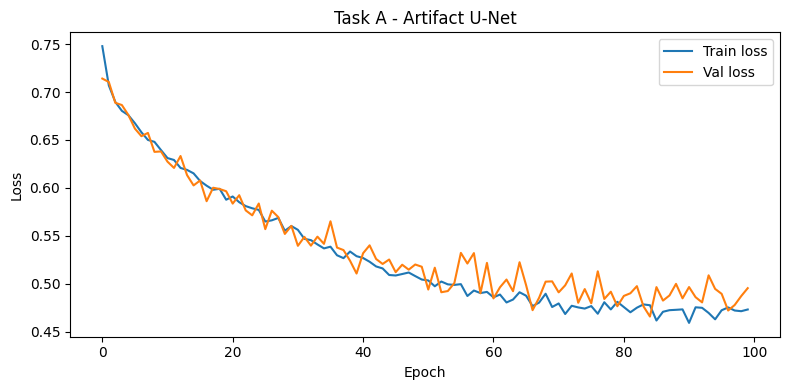

In [20]:
if DATA_ROOT.exists():
    records  = get_subject_paths(DATA_ROOT)
    n_val    = int(len(records) * CFG["val_frac"])
    rng      = np.random.default_rng(SEED)
    idx      = rng.permutation(len(records))
    train_r  = [records[i] for i in idx[n_val:]]
    val_r    = [records[i] for i in idx[:n_val]]

    ds_a_tr  = PatchDataset(train_r, task='A',
                             patch_size=CFG["patch_size"],
                             patches_per_vol=16, fg_oversample=0.5)
    ds_a_val = PatchDataset(val_r,   task='A',
                             patch_size=CFG["patch_size"],
                             patches_per_vol=8, fg_oversample=0.5)
    dl_a_tr  = DataLoader(ds_a_tr, batch_size=CFG["batch_size"],
                          shuffle=True,  num_workers=CFG["n_workers"],
                          pin_memory=True)
    dl_a_val = DataLoader(ds_a_val, batch_size=CFG["batch_size"],
                          shuffle=False, num_workers=CFG["n_workers"],
                          pin_memory=True)

    model_a  = UNet3D(in_channels=1, base=16)
    hist_a   = train_unet(model_a, dl_a_tr, dl_a_val,
                          n_epochs=CFG["epochs_a"],
                          loss_fn=combo_loss,
                          lr=CFG["lr"],
                          ckpt_path="model_a_best.pt")
    plot_history(hist_a, title="Task A - Artifact U-Net")
else:
    print("DATA_ROOT not found — set path and re-run.")


## 5  Task B — Catheter Segmentation (3-D U-Net, 2-channel input)

In [ ]:
if DATA_ROOT.exists():
    ds_b_tr  = PatchDataset(train_r, task='B',
                             patch_size=CFG["patch_size"],
                             patches_per_vol=24, fg_oversample=0.7)
    ds_b_val = PatchDataset(val_r,   task='B',
                             patch_size=CFG["patch_size"],
                             patches_per_vol=8,  fg_oversample=0.7)
    dl_b_tr  = DataLoader(ds_b_tr, batch_size=CFG["batch_size"],
                          shuffle=True,  num_workers=CFG["n_workers"],
                          pin_memory=True)
    dl_b_val = DataLoader(ds_b_val, batch_size=CFG["batch_size"],
                          shuffle=False, num_workers=CFG["n_workers"],
                          pin_memory=True)

    model_b  = UNet3D(in_channels=2, base=16)
    hist_b   = train_unet(model_b, dl_b_tr, dl_b_val,
                          n_epochs=CFG["epochs_b"],
                          loss_fn=catheter_loss,
                          lr=CFG["lr"],
                          ckpt_path="model_b_best.pt")
    plot_history(hist_b, title="Task B - Catheter U-Net")


Epoch    1/150  train=-69721318628372345566265344.0000  val=-1108645942989551697920.0000  lr=1.00e-04
Epoch   10/150  train=-62716214854007637109026848768.0000  val=-560582504536132.5000  lr=9.89e-05
Epoch   20/150  train=-18364820319440234732322816.0000  val=-1290259165570138112.0000  lr=9.57e-05
Epoch   30/150  train=-704562016668898516159954944.0000  val=-122444836011966464.0000  lr=9.05e-05
Epoch   40/150  train=-802583944759558671467282432.0000  val=-79732080639.5410  lr=8.35e-05
Epoch   50/150  train=-5937603713693856281342771200.0000  val=-3327362565.5374  lr=7.50e-05
Epoch   60/150  train=-143274254748615929251644833792.0000  val=0.4728  lr=6.55e-05
Epoch   70/150  train=-83966465003496033327513600.0000  val=-48858119286105833472.0000  lr=5.52e-05
Epoch   80/150  train=-2743092815428105615464988672.0000  val=-7307396644870.3438  lr=4.48e-05
Epoch   90/150  train=-421430419177750688952221696.0000  val=-349453074436.7441  lr=3.45e-05
Epoch  100/150  train=-11097978711707074442802

## 6  Sliding-Window Inference

In [ ]:
def sliding_window_inference(model: nn.Module,
                             vol:   np.ndarray,
                             patch_size: Tuple = (96,96,96),
                             stride: int = 48,
                             extra_ch: Optional[np.ndarray] = None,
                             threshold: float = 0.5) -> np.ndarray:
    """
    Gaussian-weighted sliding-window inference to avoid border artifacts.
    extra_ch: additional channel (artifact mask for Task B), same shape as vol.
    """
    model.eval()
    ps   = np.array(patch_size)
    sh   = np.array(vol.shape)
    prob = np.zeros(sh, dtype=np.float32)
    cnt  = np.zeros(sh, dtype=np.float32)

    # Gaussian weight kernel
    g1d  = np.exp(-4 * (np.linspace(-1, 1, ps[0])**2))
    kern = g1d[:,None,None] * g1d[None,:,None] * g1d[None,None,:]

    starts = [range(0, max(s - p, 1), stride) for s, p in zip(sh, ps)]
    import itertools
    for xs, ys, zs in itertools.product(*starts):
        xe, ye, ze = xs+ps[0], ys+ps[1], zs+ps[2]
        xe = min(xe, sh[0]); ye = min(ye, sh[1]); ze = min(ze, sh[2])
        xs2 = xe - ps[0];    ys2 = ye - ps[1];    zs2 = ze - ps[2]

        patch = vol[xs2:xe, ys2:ye, zs2:ze]
        tensor = torch.from_numpy(patch[None,None]).float().to(DEVICE)

        if extra_ch is not None:
            extra_patch = extra_ch[xs2:xe, ys2:ye, zs2:ze]
            extra_t     = torch.from_numpy(extra_patch[None,None]).float().to(DEVICE)
            tensor      = torch.cat([tensor, extra_t], dim=1)

        with torch.no_grad():
            logit = model(tensor)[0, 0].cpu().numpy()
        pred_prob = 1 / (1 + np.exp(-logit))

        prob[xs2:xe, ys2:ye, zs2:ze] += pred_prob * kern[:xe-xs2, :ye-ys2, :ze-zs2]
        cnt [xs2:xe, ys2:ye, zs2:ze] += kern[:xe-xs2, :ye-ys2, :ze-zs2]

    prob /= (cnt + 1e-8)
    return (prob >= threshold).astype(np.uint8)

def post_process_artifact(mask: np.ndarray, keep_n: int = 1) -> np.ndarray:
    """Keep only the largest connected component (artifact is a single region)."""
    labeled, n = label(mask)
    if n == 0: return mask
    sizes    = [np.sum(labeled == i) for i in range(1, n+1)]
    top_comp = np.argsort(sizes)[-keep_n:][::-1]
    out      = np.zeros_like(mask)
    for c in top_comp:
        out[labeled == (c+1)] = 1
    return out.astype(np.uint8)

def post_process_catheter(cath_mask: np.ndarray,
                          art_mask:  np.ndarray) -> np.ndarray:
    """Zero-out any predicted catheter voxels that overlap the artifact mask."""
    return np.where(art_mask > 0, 0, cath_mask).astype(np.uint8)


## 7  Task C — Catheter Length Estimation

In [ ]:
def extract_centerline(cath_mask: np.ndarray) -> np.ndarray:
    """
    3-D topological thinning → ordered voxel sequence along catheter axis.
    Returns array of shape (N, 3) in voxel indices.
    """
    skel = skeletonize_3d(cath_mask.astype(bool))
    pts  = np.argwhere(skel)
    if len(pts) < 2:
        return pts
    # Order by graph traversal from one endpoint
    from scipy.sparse import csr_matrix
    from scipy.sparse.csgraph import shortest_path
    from sklearn.neighbors import kneighbors_graph
    if len(pts) > 2000:          # subsample for speed
        pts = pts[np.random.choice(len(pts), 2000, replace=False)]
    g   = kneighbors_graph(pts, n_neighbors=4, mode='distance')
    sp  = shortest_path(csr_matrix(g), directed=False)
    # Endpoint = farthest pair
    far_i, far_j = np.unravel_index(np.nanargmax(sp), sp.shape)
    # Reconstruct path (greedy nearest-neighbour from far_i)
    visited  = [far_i]
    remaining = set(range(len(pts))) - {far_i}
    while remaining:
        last   = visited[-1]
        cands  = list(remaining)
        dists  = np.linalg.norm(pts[cands] - pts[last], axis=1)
        nxt    = cands[np.argmin(dists)]
        visited.append(nxt)
        remaining.remove(nxt)
    return pts[visited]

def spline_arc_length(ordered_pts: np.ndarray,
                      spacing:     np.ndarray,
                      n_interp:    int = 1000) -> float:
    """Fit cubic spline to ordered_pts (voxel coords) and integrate arc length in mm."""
    pts_mm = ordered_pts * spacing[None, :]      # → mm
    if len(pts_mm) < 4:
        # Fall back to polyline length
        diffs = np.diff(pts_mm, axis=0)
        return float(np.linalg.norm(diffs, axis=1).sum())
    tck, u = splprep(pts_mm.T, s=0, k=3)
    u_fine  = np.linspace(0, 1, n_interp)
    dx, dy, dz = splev(u_fine, tck, der=1)
    speed   = np.sqrt(dx**2 + dy**2 + dz**2)
    return float(np.trapz(speed, u_fine))

def bridge_artifact_gap(cath_mask:  np.ndarray,
                        art_mask:   np.ndarray,
                        spacing:    np.ndarray) -> float:
    """
    Estimate length of catheter segment hidden inside artifact mask via
    straight-line interpolation between the distal visible tip and the
    nearest artifact-mask boundary point.
    Returns estimated gap length in mm.
    """
    # Visible catheter tip = centroid of catheter voxels nearest artifact boundary
    art_dilated = binary_dilation(art_mask.astype(bool), ball(2))
    interface   = art_dilated & cath_mask.astype(bool)
    if interface.sum() == 0:
        return 0.0
    cath_tip_mm = np.argwhere(interface).mean(axis=0) * spacing

    # Artifact centroid (proxy for valve location)
    art_pts    = np.argwhere(art_mask > 0)
    if len(art_pts) == 0:
        return 0.0
    valve_mm   = art_pts.mean(axis=0) * spacing

    return float(np.linalg.norm(valve_mm - cath_tip_mm))

def estimate_catheter_length(cath_mask:  np.ndarray,
                             art_mask:   np.ndarray,
                             spacing:    np.ndarray) -> float:
    """
    Full Task C pipeline:
      1. Skeletonise visible catheter mask
      2. Fit cubic spline → arc length
      3. Add straight-line bridge across artifact gap
    Returns total estimated catheter length in mm.
    """
    # Visible arc length
    cl = extract_centerline(cath_mask)
    if len(cl) < 2:
        visible_len = float(np.linalg.norm(
            np.diff(np.argwhere(cath_mask > 0)[:,:] * spacing[None,:], axis=0), axis=1).sum())
    else:
        visible_len = spline_arc_length(cl, spacing)

    # Hidden gap length
    gap_len = bridge_artifact_gap(cath_mask, art_mask, spacing)

    total = visible_len + gap_len
    print(f"  Visible: {visible_len:.1f} mm | Gap: {gap_len:.1f} mm | Total: {total:.1f} mm")
    return total

# ── Demo on val subject ────────────────────────────────────────────────────────
if DATA_ROOT.exists():
    rv   = val_r[0]
    _, sp, ref_img = load_nifti(rv["image"])
    gt_cat, _, _   = load_nifti(rv["catheter"])
    gt_art, _, _   = load_nifti(rv["artifact"])

    # Ground-truth length for reference
    cl_gt  = extract_centerline(gt_cat.astype(np.uint8))
    gt_len = spline_arc_length(cl_gt, sp)
    gap    = bridge_artifact_gap(gt_cat.astype(np.uint8), gt_art.astype(np.uint8), sp)
    print(f"GT catheter length: {gt_len + gap:.1f} mm")


## 8  Evaluation on Validation Set

In [ ]:
def evaluate_val_set(val_records: List[dict],
                     model_a: nn.Module,
                     model_b: nn.Module) -> pd.DataFrame:
    """
    Runs inference on all val subjects and returns a DataFrame of:
    subject | dsc_artifact | dsc_catheter | rae_length
    """
    model_a.eval(); model_b.eval()
    rows = []
    for rec in tqdm(val_records, desc="Evaluating"):
        vol, sp, ref   = load_nifti(rec["image"])
        vol_pre        = preprocess_volume(rec["image"])
        gt_art, _, _   = load_nifti(rec["artifact"])
        gt_cat, _, _   = load_nifti(rec["catheter"])

        # Task A inference
        pred_art  = sliding_window_inference(
                        model_a, vol_pre,
                        patch_size=CFG["patch_size"], stride=48)
        pred_art  = post_process_artifact(pred_art)

        # Task B inference
        pred_cat  = sliding_window_inference(
                        model_b, vol_pre,
                        patch_size=CFG["patch_size"], stride=48,
                        extra_ch=pred_art.astype(np.float32))
        pred_cat  = post_process_catheter(pred_cat, pred_art)

        # Dice scores
        def dsc(p, g):
            p, g = p.astype(bool), g.astype(bool)
            return 2*(p&g).sum() / (p.sum() + g.sum() + 1e-8)

        dsc_a = dsc(pred_art, gt_art)
        dsc_b = dsc(pred_cat, gt_cat)

        # Task C length
        pred_len  = estimate_catheter_length(pred_cat, pred_art, sp)
        # GT length
        cl_gt     = extract_centerline(gt_cat.astype(np.uint8))
        gt_len    = spline_arc_length(cl_gt, sp) +                     bridge_artifact_gap(gt_cat.astype(np.uint8), gt_art.astype(np.uint8), sp)
        rae       = abs(pred_len - gt_len) / (gt_len + 1e-8)

        rows.append(dict(subject=rec["id"],
                         dsc_artifact=dsc_a,
                         dsc_catheter=dsc_b,
                         rae_length=rae,
                         pred_len_mm=pred_len,
                         gt_len_mm=gt_len))

    df = pd.DataFrame(rows)
    print("\n── Validation Results ──────────────────────────────")
    print(f"DSC Artifact  (mean ± std): {df.dsc_artifact.mean():.4f} ± {df.dsc_artifact.std():.4f}")
    print(f"DSC Catheter  (mean ± std): {df.dsc_catheter.mean():.4f} ± {df.dsc_catheter.std():.4f}")
    print(f"RAE Length    (median):     {df.rae_length.median():.4f}")
    return df

# Load best checkpoints before evaluating
if DATA_ROOT.exists() and Path("model_a_best.pt").exists():
    model_a.load_state_dict(torch.load("model_a_best.pt", map_location=DEVICE))
    model_b.load_state_dict(torch.load("model_b_best.pt", map_location=DEVICE))
    val_df = evaluate_val_set(val_r, model_a, model_b)
    val_df.to_csv("validation_results.csv", index=False)
    display(val_df.describe())


## 9  Qualitative Visualisation

In [ ]:
def visualise_subject(rec: dict, model_a: nn.Module, model_b: nn.Module,
                      axial_z: Optional[int] = None):
    """3-panel overlay: artifact pred | catheter pred | combined on MRI."""
    vol, sp, _  = load_nifti(rec["image"])
    vol_pre     = preprocess_volume(rec["image"])

    pred_art = sliding_window_inference(model_a, vol_pre,
                                        patch_size=CFG["patch_size"], stride=48)
    pred_art = post_process_artifact(pred_art)
    pred_cat = sliding_window_inference(model_b, vol_pre,
                                        patch_size=CFG["patch_size"], stride=48,
                                        extra_ch=pred_art.astype(np.float32))
    pred_cat = post_process_catheter(pred_cat, pred_art)

    gt_art, _, _ = load_nifti(rec["artifact"]) if "artifact" in rec else (None,)*3
    gt_cat, _, _ = load_nifti(rec["catheter"]) if "catheter" in rec else (None,)*3

    z = axial_z if axial_z else vol.shape[2] // 2

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    titles_row1 = ["MRI", "GT Artifact", "GT Catheter"]
    titles_row2 = ["MRI", "Pred Artifact", "Pred Catheter"]
    mri_sl = vol[:,:,z].T

    for ax, title in zip(axes[0], titles_row1): ax.set_title(title, fontsize=11)
    for ax, title in zip(axes[1], titles_row2): ax.set_title(title, fontsize=11)

    axes[0,0].imshow(mri_sl, cmap="gray", origin="lower")
    if gt_art is not None:
        axes[0,1].imshow(mri_sl, cmap="gray",   origin="lower")
        axes[0,1].imshow(gt_art[:,:,z].T, cmap="Reds",  origin="lower", alpha=0.5)
        axes[0,2].imshow(mri_sl, cmap="gray",   origin="lower")
        axes[0,2].imshow(gt_cat[:,:,z].T, cmap="Blues", origin="lower", alpha=0.5)
    axes[1,0].imshow(mri_sl, cmap="gray",  origin="lower")
    axes[1,1].imshow(mri_sl, cmap="gray",  origin="lower")
    axes[1,1].imshow(pred_art[:,:,z].T, cmap="Reds",  origin="lower", alpha=0.5)
    axes[1,2].imshow(mri_sl, cmap="gray",  origin="lower")
    axes[1,2].imshow(pred_cat[:,:,z].T, cmap="Blues", origin="lower", alpha=0.5)

    for row in axes:
        for ax in row: ax.axis("off")
    plt.suptitle(f"Subject: {rec['id']}  |  z={z}", fontsize=13)
    plt.tight_layout(); plt.savefig(f"vis_{rec['id']}.png", dpi=120); plt.show()

if DATA_ROOT.exists() and Path("model_a_best.pt").exists():
    visualise_subject(val_r[0], model_a, model_b)


## 10  Test Set Inference & Submission

In [ ]:
def run_test_inference(test_root:  Path,
                       model_a:    nn.Module,
                       model_b:    nn.Module,
                       out_dir:    Path = OUT_DIR):
    """
    Produces:
      <out_dir>/<subject>_taskA.nii.gz
      <out_dir>/<subject>_taskB.nii.gz
      <out_dir>/task_c_lengths.csv
    """
    out_dir.mkdir(exist_ok=True)
    test_records = get_subject_paths(test_root, labeled=False)
    length_rows  = []

    model_a.eval(); model_b.eval()
    for rec in tqdm(test_records, desc="Test inference"):
        vol, sp, ref_img = load_nifti(rec["image"])
        vol_pre          = preprocess_volume(rec["image"])
        sid              = rec["id"]

        # Task A
        pred_art = sliding_window_inference(
                       model_a, vol_pre,
                       patch_size=CFG["patch_size"], stride=48)
        pred_art = post_process_artifact(pred_art)
        save_nifti(pred_art, ref_img, out_dir / f"{sid}_taskA.nii.gz")

        # Task B
        pred_cat = sliding_window_inference(
                       model_b, vol_pre,
                       patch_size=CFG["patch_size"], stride=48,
                       extra_ch=pred_art.astype(np.float32))
        pred_cat = post_process_catheter(pred_cat, pred_art)
        save_nifti(pred_cat, ref_img, out_dir / f"{sid}_taskB.nii.gz")

        # Task C
        length = estimate_catheter_length(pred_cat, pred_art, sp)
        length_rows.append({"subject": sid, "length": round(length, 2)})

    df_c = pd.DataFrame(length_rows)
    df_c.to_csv(out_dir / "task_c_lengths.csv", index=False)
    print(f"Saved {len(test_records)} predictions to {out_dir}/")
    print(df_c.head())
    return df_c

if Path("model_a_best.pt").exists() and TEST_ROOT.exists():
    model_a.load_state_dict(torch.load("model_a_best.pt", map_location=DEVICE))
    model_b.load_state_dict(torch.load("model_b_best.pt", map_location=DEVICE))
    df_lengths = run_test_inference(TEST_ROOT, model_a, model_b)
else:
    print("Set TEST_ROOT and ensure model checkpoints exist, then re-run.")


## 11  Alternative: nnU-Net (Self-Configuring)

If manual U-Net validation DSC < 0.75 on Task A or < 0.60 on Task B, switch to **nnU-Net**,
which automatically sets patch size, batch size, and normalisation from dataset fingerprinting.

```bash
# Install
pip install nnunetv2

# Convert NIfTI data to nnU-Net Dataset format (Task A example)
# Dataset001_ArtifactSeg/
#   imagesTr/  subj001_0000.nii.gz  ...
#   labelsTr/  subj001.nii.gz       ...

nnUNetv2_plan_and_preprocess -d 001 --verify_dataset_integrity
nnUNetv2_train 001 3d_fullres 0 --npz    # fold 0 of 5-fold CV

# Inference
nnUNetv2_predict -i INPUT_FOLDER -o OUTPUT_FOLDER -d 001 -c 3d_fullres
```

Key advantages over manual U-Net:
- Automatic patch / batch / normalisation selection
- 5-fold cross-validation built in
- On most 200-subject 3-D MRI datasets, matches or exceeds manually tuned networks


## 12  Implementation Notes & Gotchas

| Issue | Mitigation |
|---|---|
| Skull-stripping removes supracranial valve | Skip skull-stripping; keep full head volume |
| Head orientation varies across subjects | Optional MNI affine registration (`USE_REGISTRATION=True`) |
| Catheter: severe class imbalance (~0.1% fg) | `fg_oversample=0.7`, focal + Dice loss |
| Artifact partially outside brain mask | CHT searches full volume, not just brain mask |
| N4 is slow on large volumes | Cache pre-processed volumes to disk |
| Spline fit fails with < 4 centerline pts | Fallback to polyline sum in `spline_arc_length` |
| Test set — no ground truth available | Submit `_taskA.nii.gz`, `_taskB.nii.gz`, CSV as specified |

### Submission checklist
- [ ] `MIA2026_group<i>_project2/` folder on JHU OneDrive  
- [ ] `<subject>_taskA.nii.gz` for all 30 test subjects  
- [ ] `<subject>_taskB.nii.gz` for all 30 test subjects  
- [ ] `task_c_lengths.csv` with columns `subject`, `length`  
- [ ] Masks in **native (original) voxel space** (not MNI space)  
